# Credit Card Fraud Detection

A binary classification project to detect **fraudulent credit card transactions** under extreme class imbalance (only ~0.29% of transactions are fraud). The goal is to gain practical experience in **evaluating models honestly** and **choosing the right tool for the data**.

This notebook is organized to run top-to-bottom in a single pass, reproducing the full pipeline.

**Flow:** Data exploration → Preprocessing (split & scaling) → Baseline (Logistic Regression) → Evaluation metrics → Threshold tuning → Random Forest → Imbalance handling (class_weight & SMOTE) → Neural Net (MLP) → Comparison table

> Data: [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — place `creditcard.csv` in the same folder as this notebook before running.


## 0. Setup

Import all shared libraries up front. (Includes Korean font setup for plots, optional.)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score,
)

RANDOM_STATE = 42   # fixed seed across the whole pipeline for reproducibility

## 1. Load & Explore the Data

Load the data and check its size, missing values, and class distribution.


In [2]:
df = pd.read_csv('creditcard.csv')
print("Data shape:", df.shape)
df.head()

Data shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Check for missing values, then drop them
print("Rows with missing values:", df.isnull().any(axis=1).sum())
df = df.dropna()
print("Shape after cleaning:", df.shape)

Rows with missing values: 0
Shape after cleaning: (284807, 31)


### Class imbalance — the heart of this project

Fraud (class 1) makes up less than 0.3% of the data. This imbalance makes both evaluation and training hard.


In [4]:
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True))
# 0 = normal, 1 = fraud

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


### Transaction amount distribution — normal vs fraud

Overlay the amount distributions of normal and fraudulent transactions.


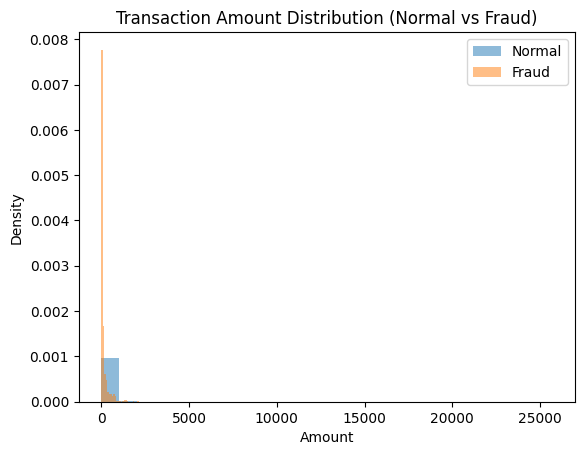

In [5]:
fraud_amount  = df[df['Class'] == 1]['Amount']
normal_amount = df[df['Class'] == 0]['Amount']

plt.hist(normal_amount, bins=25, alpha=0.5, label='Normal', density=True)
plt.hist(fraud_amount,  bins=25, alpha=0.5, label='Fraud',  density=True)
plt.legend()
plt.xlabel('Amount'); plt.ylabel('Density')
plt.title('Transaction Amount Distribution (Normal vs Fraud)')
plt.show()

## 2. Preprocessing — Train/Test Split and Scaling

**Leakage prevention:** split into train/test *first*, then fit the scaler **on the training set only**.
The test set only gets `transform` using parameters learned from train. If test information leaks into
training, scores get unrealistically inflated.

`stratify=y` keeps the fraud ratio identical in both train and test (essential under extreme imbalance).


In [6]:
X = df.drop(columns='Class')
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,            # keep the fraud ratio identical in train/test
    random_state=RANDOM_STATE,
)

print("train class ratio:\n", y_train.value_counts(normalize=True), sep="")
print("\ntest class ratio:\n",  y_test.value_counts(normalize=True),  sep="")

train class ratio:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

test class ratio:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [7]:
# Scale only Amount and Time (V1-V28 are already PCA-processed and well-scaled)
cols_to_scale = ['Amount', 'Time']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# Fit the scaler on train only, then transform test (prevents leakage)
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

## 3. Baseline — Logistic Regression

Start with the simplest model to establish a reference point, and demonstrate the **"accuracy trap"** directly.


In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

### Accuracy lies

Compared with a model that blindly predicts "normal" (0) for everything, accuracy can barely tell them apart.
Even missing every fraud still yields ~99.7% accuracy → accuracy is useless for this problem.


In [9]:
print("My model accuracy:", accuracy_score(y_test, y_pred))

dummy_pred = [0] * len(y_test)   # lazy model that calls everything normal
print("Predict-all-normal accuracy:", accuracy_score(y_test, dummy_pred))

My model accuracy: 0.9991573329588147
Predict-all-normal accuracy: 0.9982795547909132


## 4. Proper Evaluation — Confusion Matrix, Precision, Recall

Instead of accuracy, focus on the fraud (class 1). In sklearn the confusion matrix is laid out as
`[[TN, FP], [FN, TP]]`.


In [10]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
# [[TN  FP]
#  [FN  TP]]   <- FN (missed fraud) is the most expensive mistake here

[[56851    13]
 [   35    63]]


In [11]:
# Per-class precision/recall/f1 — the row that matters is class 1 (fraud)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56864
           1     0.8289    0.6429    0.7241        98

    accuracy                         0.9992     56962
   macro avg     0.9142    0.8213    0.8619     56962
weighted avg     0.9991    0.9992    0.9991     56962



### PR-curve and PR-AUC

The model internally outputs probabilities (`predict_proba`). Sweeping the threshold that cuts those
probabilities from 0 to 1 traces how precision/recall change — that's the PR-curve, and the area under it
is PR-AUC. Under imbalance it's more honest than ROC because it isn't polluted by the huge TN count.


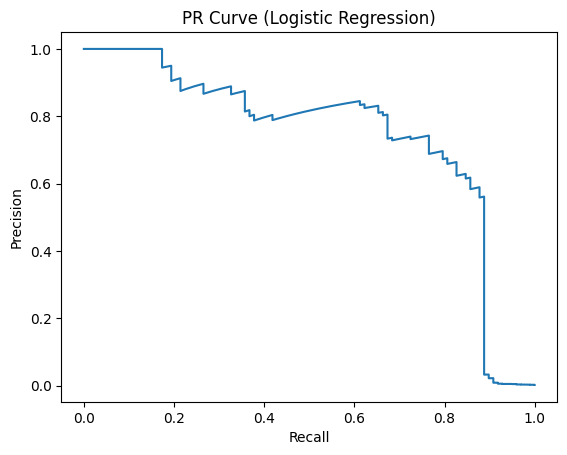

Baseline PR-AUC: 0.7431691767832421


In [12]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]   # [:, 1] = probability of fraud

prec, rec, thr = precision_recall_curve(y_test, y_proba)
plt.plot(rec, prec)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('PR Curve (Logistic Regression)')
plt.show()

print("Baseline PR-AUC:", average_precision_score(y_test, y_proba))

## 5. Threshold Tuning — Turning the Trade-off by Hand

The default threshold of 0.5 is not sacred. Lowering it catches more fraud (recall up) but raises false
alarms (precision down); raising it does the opposite. The table below shows how the two metrics trade off
across thresholds.


In [13]:
for t in [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
    y_pred_t = (y_proba >= t).astype(int)   # predict fraud (1) if probability >= t
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    print(f"threshold={t}: precision={p:.3f}, recall={r:.3f}")

threshold=0.1: precision=0.701, recall=0.765
threshold=0.2: precision=0.737, recall=0.745
threshold=0.3: precision=0.728, recall=0.684
threshold=0.5: precision=0.829, recall=0.643
threshold=0.7: precision=0.833, recall=0.612
threshold=0.9: precision=0.823, recall=0.520


## 6. Second Model — Random Forest

A reference point is needed to judge whether the baseline is any good. Random Forest is a majority vote of
many decision trees and is often strong on tabular data.


In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_pred  = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]

print("LogReg       PR-AUC:", average_precision_score(y_test, y_proba))
print("RandomForest PR-AUC:", average_precision_score(y_test, rf_proba))
print(classification_report(y_test, rf_pred, digits=4))

LogReg       PR-AUC: 0.7431691767832421
RandomForest PR-AUC: 0.8733910547021404
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9412    0.8163    0.8743        98

    accuracy                         0.9996     56962
   macro avg     0.9704    0.9081    0.9371     56962
weighted avg     0.9996    0.9996    0.9996     56962



## 7. Imbalance Handling (1) — class_weight='balanced'

Leave the data as is, but **increase the penalty for misclassifying fraud**. Weights are assigned
automatically in inverse proportion to class frequency. The cheapest method — just one extra argument.


In [15]:
model_w = LogisticRegression(max_iter=1000, class_weight='balanced')
model_w.fit(X_train_scaled, y_train)
y_pred_w  = model_w.predict(X_test_scaled)
y_proba_w = model_w.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_w, digits=4))
print("class_weight PR-AUC:", average_precision_score(y_test, y_proba_w))

              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962

class_weight PR-AUC: 0.7159122424484009


## 7. Imbalance Handling (2) — SMOTE (Oversampling)

Synthesize artificial fraud examples to balance the classes. **To prevent leakage, SMOTE must be applied to
the training set only.** Using `imblearn`'s Pipeline applies SMOTE only during fitting and automatically
skips it at prediction (test) time, blocking leakage structurally.

> Note: you must use `imblearn.pipeline.Pipeline`. sklearn's Pipeline cannot handle resamplers.


In [16]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Pipeline: SMOTE is applied only during fit -> automatically skipped on test (leakage blocked)
pipe = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(max_iter=1000)),
])

pipe.fit(X_train_scaled, y_train)        # SMOTE applied only during training
y_pred_s  = pipe.predict(X_test_scaled)  # test is evaluated on the original data
y_proba_s = pipe.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_s, digits=4))
print("SMOTE PR-AUC:", average_precision_score(y_test, y_proba_s))

              precision    recall  f1-score   support

           0     0.9999    0.9743    0.9869     56864
           1     0.0580    0.9184    0.1092        98

    accuracy                         0.9742     56962
   macro avg     0.5289    0.9463    0.5480     56962
weighted avg     0.9982    0.9742    0.9854     56962

SMOTE PR-AUC: 0.7249139606556327


### Store baseline metrics as variables

Save the baseline predictions/probabilities separately for the final comparison table.


In [17]:
y_pred_base  = y_pred     # baseline predictions from section 3
y_proba_base = y_proba     # baseline probabilities from section 4

## 8. Neural Net (MLP) — PyTorch

Solve the same problem with a neural net and compare it against the sklearn models. A small multi-layer
perceptron with the structure: input -> Linear -> ReLU -> Linear -> output(1).


In [18]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


### Prepare training data

Split the training set again into a training part (tr) and a validation part (val). The validation set is
not used for training — it only monitors overfitting each epoch. Neural net inputs must be floats, and the
labels y are reshaped to `[N, 1]` to match the model output.


In [19]:
# Split train again into tr/val (to hold out a validation set)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

# pandas -> tensors (float32, on the same device)
X_tr_t  = torch.tensor(X_tr.values,  dtype=torch.float32, device=device)
y_tr_t  = torch.tensor(y_tr.values,  dtype=torch.float32, device=device).view(-1, 1)
X_val_t = torch.tensor(X_val.values, dtype=torch.float32, device=device)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32, device=device).view(-1, 1)

# DataLoader feeds the data in batches
train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)

### Model, loss function, optimizer

`BCEWithLogitsLoss` applies the sigmoid internally, so the model outputs raw logits only.
`pos_weight` is the neural-net counterpart of class_weight — it raises the penalty for misclassifying fraud.


In [20]:
n_features = X_train_scaled.shape[1]
model_nn = nn.Sequential(
    nn.Linear(n_features, 32),
    nn.ReLU(),
    nn.Linear(32, 1),          # output 1 = fraud logit
)
model_nn.to(device)

# Imbalance handling: penalize misclassified fraud (1) more than normal
n_pos = (y_tr == 1).sum()
n_neg = (y_tr == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)

loss_fn   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=1e-3)

### Training loop

Repeat the four steps — forward -> loss -> backward -> step — for every batch. At the end of each epoch,
print the validation loss alongside the training loss to check that both go down together (no overfitting).


In [21]:
n_epochs = 20
for epoch in range(n_epochs):
    model_nn.train()
    running = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()            # reset gradients
        pred = model_nn(X_batch)         # forward
        loss = loss_fn(pred, y_batch)    # loss
        loss.backward()                  # backward
        optimizer.step()                 # step (update weights)
        running += loss.item()
    train_loss = running / len(train_loader)

    model_nn.eval()
    with torch.no_grad():                # validation: no gradient tracking
        val_loss = loss_fn(model_nn(X_val_t), y_val_t).item()
    print(f"epoch{epoch+1:2d}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

epoch 1: train_loss=0.7038, val_loss=0.4980
epoch 2: train_loss=0.3273, val_loss=0.4350
epoch 3: train_loss=0.2598, val_loss=0.4449
epoch 4: train_loss=0.2331, val_loss=0.4483
epoch 5: train_loss=0.2144, val_loss=0.4636
epoch 6: train_loss=0.2045, val_loss=0.4725
epoch 7: train_loss=0.1881, val_loss=0.4824
epoch 8: train_loss=0.1796, val_loss=0.4839
epoch 9: train_loss=0.1672, val_loss=0.4917
epoch10: train_loss=0.1624, val_loss=0.4992
epoch11: train_loss=0.1516, val_loss=0.5393
epoch12: train_loss=0.1449, val_loss=0.5431
epoch13: train_loss=0.1367, val_loss=0.5589
epoch14: train_loss=0.1311, val_loss=0.5657
epoch15: train_loss=0.1229, val_loss=0.5989
epoch16: train_loss=0.1189, val_loss=0.6101
epoch17: train_loss=0.1115, val_loss=0.6640
epoch18: train_loss=0.1041, val_loss=0.6553
epoch19: train_loss=0.1014, val_loss=0.6841
epoch20: train_loss=0.0949, val_loss=0.7123


### Evaluate the neural net — on the original test set

Evaluate the trained model on the test set. During training the loss function handled the sigmoid, but to
read probabilities directly here we apply `torch.sigmoid` to convert logits into probabilities (0-1).


In [22]:
X_test_t = torch.tensor(X_test_scaled.values, dtype=torch.float32, device=device)

model_nn.eval()
with torch.no_grad():
    nn_proba = torch.sigmoid(model_nn(X_test_t)).cpu().numpy().ravel()  # logits -> probabilities
nn_pred = (nn_proba >= 0.5).astype(int)                                 # cut at 0.5 into 0/1

print(classification_report(y_test, nn_pred, digits=4))
print("Neural Net PR-AUC:", average_precision_score(y_test, nn_proba))

              precision    recall  f1-score   support

           0     0.9998    0.9827    0.9912     56864
           1     0.0829    0.9082    0.1520        98

    accuracy                         0.9826     56962
   macro avg     0.5414    0.9454    0.5716     56962
weighted avg     0.9983    0.9826    0.9897     56962

Neural Net PR-AUC: 0.711314419941517


## 9. Final Comparison Table

Compare all models on the **same original test set** with the same metrics (default threshold 0.5).
This table is the core evidence of the project. See the README for the full interpretation.


In [23]:
def report(name, y_true, y_pred, y_proba):
    print(f"[{name:13s}] "
          f"P={precision_score(y_true, y_pred):.3f}  "
          f"R={recall_score(y_true, y_pred):.3f}  "
          f"F1={f1_score(y_true, y_pred):.3f}  "
          f"PR-AUC={average_precision_score(y_true, y_proba):.3f}")

report("Baseline",     y_test, y_pred_base, y_proba_base)
report("RandomForest", y_test, rf_pred,     rf_proba)
report("class_weight", y_test, y_pred_w,    y_proba_w)
report("SMOTE",        y_test, y_pred_s,    y_proba_s)
report("Neural Net",   y_test, nn_pred,     nn_proba)

[Baseline     ] P=0.829  R=0.643  F1=0.724  PR-AUC=0.743
[RandomForest ] P=0.941  R=0.816  F1=0.874  PR-AUC=0.873
[class_weight ] P=0.061  R=0.918  F1=0.114  PR-AUC=0.716
[SMOTE        ] P=0.058  R=0.918  F1=0.109  PR-AUC=0.725
[Neural Net   ] P=0.083  R=0.908  F1=0.152  PR-AUC=0.711
